## 01. Scratchpad

### 1. Uploading .tsv file

In [1]:
import Data
import matplotlib.pyplot as plt

In [2]:
path = '../data/tatoeba_1/eng-pol_1.tsv'
df = Data.upload_tsv(path=path, col_drop=[0, 2])
df.head(3)

,eng_text,pol_text
0,Let's try something.,Spróbujmy coś.
1,I have to go to sleep.,Muszę iść spać.
2,Muiriel is 20 now.,Muiriel ma teraz 20 lat.


### 2. Sentence tokenization

In [3]:
df_tok = Data.tokenize_data(df=df, src_col='eng_text', tgt_col='pol_text')
df_tok.head(3)

,eng_text,pol_text,eng_len,pol_len
0,"[lets, try, something, ., <eos>]","[<bos>, spróbujmy, coś, ., <eos>]",5,5
1,"[i, have, to, go, to, sleep, ., <eos>]","[<bos>, muszę, iść, spać, ., <eos>]",8,6
2,"[muiriel, is, 20, now, ., <eos>]","[<bos>, muiriel, ma, teraz, 20, lat, ., <eos>]",6,8


### 3. Data Trimming

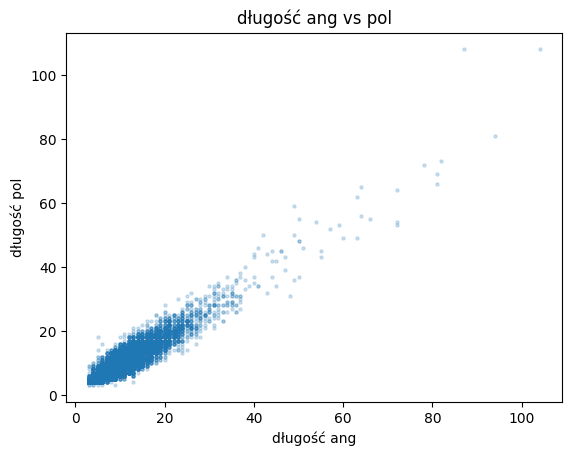

In [4]:
plt.scatter(df_tok['eng_len'], df_tok['pol_len'], alpha=0.2, s=5)
plt.xlabel('długość ang')
plt.ylabel('długość pol')
plt.title('długość ang vs pol')
plt.show()

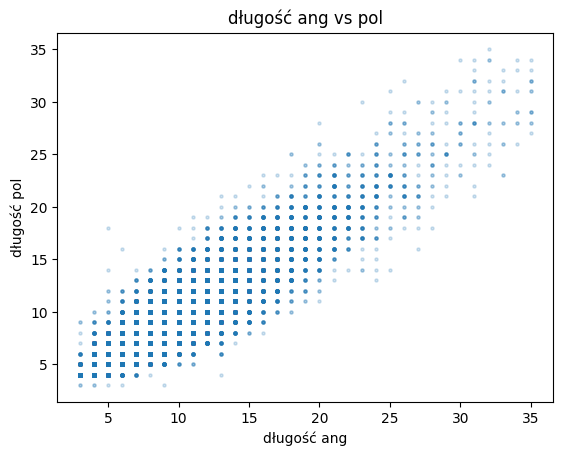

In [5]:
df_trim = Data.trim_data(df=df_tok, src_len='eng_len', tgt_len='pol_len', thres=35)

plt.scatter(df_trim['eng_len'], df_trim['pol_len'], alpha=0.2, s=5)
plt.xlabel('długość ang')
plt.ylabel('długość pol')
plt.title('długość ang vs pol')
plt.show()

### 4. Setting Vocabs

In [6]:
df_ids, eng_vocab, pol_vocab = Data.tokens_to_id(df=df_trim, src_col='eng_text', tgt_col='pol_text')
df_ids.head(3)

,eng_text,pol_text,eng_len,pol_len,src_ids,tgt_ids
0,"[lets, try, something, ., <eos>]","[<bos>, spróbujmy, coś, ., <eos>]",5,5,"[158, 270, 122, 3, 2]","[3, 3408, 68, 4, 2]"
1,"[i, have, to, go, to, sleep, ., <eos>]","[<bos>, muszę, iść, spać, ., <eos>]",8,6,"[5, 20, 6, 54, 6, 325, 3, 2]","[3, 89, 104, 294, 4, 2]"
2,"[muiriel, is, 20, now, ., <eos>]","[<bos>, muiriel, ma, teraz, 20, lat, ., <eos>]",6,8,"[3448, 11, 1746, 94, 3, 2]","[3, 4379, 26, 75, 1345, 115, 4, 2]"


In [7]:
print(list(eng_vocab.items())[:10], '\n')
print(list(pol_vocab.items())[:10], '\n')

[('<pad>', 0), ('<unk>', 1), ('<eos>', 2), ('.', 3), ('the', 4), ('i', 5), ('to', 6), ('you', 7), ('a', 8), ('tom', 9)] 

[('<pad>', 0), ('<unk>', 1), ('<eos>', 2), ('<bos>', 3), ('.', 4), (',', 5), ('nie', 6), ('?', 7), ('się', 8), ('tom', 9)] 



In [8]:
df_data = df_ids[['src_ids', 'tgt_ids']]
df_data.head(3)

,src_ids,tgt_ids
0,"[158, 270, 122, 3, 2]","[3, 3408, 68, 4, 2]"
1,"[5, 20, 6, 54, 6, 325, 3, 2]","[3, 89, 104, 294, 4, 2]"
2,"[3448, 11, 1746, 94, 3, 2]","[3, 4379, 26, 75, 1345, 115, 4, 2]"


### 5. Shuffling Data

In [9]:
df_train, df_val = Data.shuffle_split(df=df_data, tr_per=0.8)
print(df_train.shape)
df_train.head(3)

(67056, 2)


,src_ids,tgt_ids
0,"[5, 43, 52, 480, 3, 2]","[3, 26, 1307, 4, 2]"
1,"[111, 10, 41, 2]","[3, 83, 24, 7, 2]"
2,"[5, 471, 74, 9, 47, 196, 109, 39, 55, 30, 27, ...","[3, 28, 2649, 5, 17, 9, 276, 69, 25, 5, 18, 77..."


In [10]:
print(df_val.shape)
df_val.head(3)

(16765, 2)


,src_ids,tgt_ids
0,"[158, 486, 21, 4603, 3, 2]","[3, 7180, 151, 6209, 4, 2]"
1,"[100, 1241, 22, 1490, 6, 21, 836, 3, 2]","[3, 74, 14042, 249, 503, 13, 39, 950, 4, 2]"
2,"[9, 11, 57, 295, 57, 5, 105, 3, 2]","[3, 9, 10, 37, 497, 20, 91, 4, 2]"


### 6. Dataset Class Instance

In [13]:
train_data = Data.EngPolDataset(df_train, 'src_ids', 'tgt_ids')
val_data = Data.EngPolDataset(df_val, 'src_ids', 'tgt_ids')

In [14]:
tr_batch, val_batch = train_data.__getitem__(5), val_data.__getitem__(5)
tr_batch, '', val_batch

((tensor([ 20,   7, 196, 237,   8, 129, 556,  10,   2]),
  tensor([   3,  517,  223,  797, 4509,    7,    2])),
 '',
 (tensor([   4,  655, 3605,    3,    2]),
  tensor([   3, 1933, 7545,    4,    2])))

In [15]:
tr_batch2 = train_data.__getitem__(11)
tr_batch2

(tensor([  13,   22,  829,   12,   21,  179,   11, 1009,    3,    2]),
 tensor([   3,  914,   23,    5,   39,  573,   10, 3732,    4,    2]))

In [16]:
batch_test = (tr_batch, tr_batch2, train_data.__getitem__(10))
batch_test

((tensor([ 20,   7, 196, 237,   8, 129, 556,  10,   2]),
  tensor([   3,  517,  223,  797, 4509,    7,    2])),
 (tensor([  13,   22,  829,   12,   21,  179,   11, 1009,    3,    2]),
  tensor([   3,  914,   23,    5,   39,  573,   10, 3732,    4,    2])),
 (tensor([ 44,   7,  99, 102, 317, 473,  10,   2]),
  tensor([   3,   17,   81, 3617,  148, 2558,  968,    7,    2])))

In [17]:
Data.collate_fn(batch_test)

(tensor([[  20,    7,  196,  237,    8,  129,  556,   10,    2,    0],
         [  13,   22,  829,   12,   21,  179,   11, 1009,    3,    2],
         [  44,    7,   99,  102,  317,  473,   10,    2,    0,    0]]),
 tensor([[   3,  517,  223,  797, 4509,    7,    2,    0,    0,    0],
         [   3,  914,   23,    5,   39,  573,   10, 3732,    4,    2],
         [   3,   17,   81, 3617,  148, 2558,  968,    7,    2,    0]]),
 tensor([[ 9],
         [10],
         [ 8]]))